为了解决“单次二值状态导致 q 退化为 0/1”的问题，我在实现中引入了一个平滑/估计的节点感染概率向量 p（与 MMCA 中的 p_i 对应）。这个 p 由历史二值状态通过指数移动平均（EMA）更新得到，作为 q_i 构造与 Θ、β 的输入。这样做能在单次 MC 轨迹中保持“概率层面”的连续性，使得 MC 的感染概率与 MMCA 更一致（可通过调整 p_smooth 参数控制平滑强弱；p_smooth=0 表示直接用当前 0/1 状态，退回你之前的实现；p_smooth 越接近 1 表示更多依赖历史概率估计）。

In [2]:
"""
SISHyperMC - Monte Carlo s-SIS simulator on d=3 uniform hypergraph
Design goals:
- 清晰地把关键步骤拆成独立方法：
    * compute_qi(p, Theta) : 计算每个节点的感染概率 q_i(t)（基于 MMCA 公式）
    * update_theta(p, Theta) : 计算 Phi_e (基于 p) 并更新 Theta_e
    * infection_process(states, qi) : 使用 qi 对每个易感节点做感染试验
    * recovery_process(states) : 对每个感染节点做恢复试验
- 使用 p(t) 作为节点层面的“感染概率估计”，p 由二值状态通过 EMA 平滑得到（参数 p_smooth）
- 同步更新（recovery first then infection），并记录 rho(t) 与 <Theta>(t)
- 参数、初始值、绘图一应俱全，注释详尽，适合放入 Methods/SI
"""

import numpy as np
import random
import math
import matplotlib.pyplot as plt

def generate_hypergraph_H_n_m_3(n, kappa, seed=None, batch_size=3000):
    """生成随机 3-uniform hypergraph H(n,m,3)，去重。"""
    if seed is not None:
        np.random.seed(seed); random.seed(seed)
    d = 3
    m = int(round(n * kappa / d))
    max_possible = math.comb(n, d)
    if m > max_possible:
        raise ValueError("m > C(n,3)")
    nodes = np.arange(n)
    edges_set = set()
    while len(edges_set) < m:
        tris = np.random.choice(nodes, size=(batch_size, d), replace=True)
        for i in range(tris.shape[0]):
            row = tris[i]
            if len(np.unique(row)) < d:
                row = np.random.choice(nodes, size=(d,), replace=False)
            tris[i] = np.sort(row)
        for row in tris:
            if len(edges_set) >= m: 
                break
            edges_set.add(tuple(row.tolist()))
    hyperedges = np.array(list(edges_set), dtype=int)
    hyperedges.sort(axis=1)
    return hyperedges


class SISHyperMC:
    """
    Monte-Carlo s-SIS on 3-uniform hypergraph with hyperedge activity Θ and SIP-based Θ-update.
    Key design:
      - p: node-level estimated infection probability vector (float in [0,1]), updated by EMA from binary states
      - q_i(t): infection probability used for trial on susceptible node i, computed from p and Theta
      - Theta update uses Phi_e(t) = product_j p_j (MMCA-style SIP)
    """

    def __init__(self, hyperedges, n,
                 beta_d=0.3, mu=0.2, eta=1.0, gamma=0.05,
                 T=100, init_frac=0.3, seed=None, p_smooth=0.6):
        """
        初始化模型与参数。

        参数:
        - hyperedges: numpy array (m,3) of triples (sorted per row)
        - n: 节点总数
        - beta_d, mu: 传播与恢复概率（beta_d 用于 q_i 中）
        - eta, gamma: Theta 更新参数
        - T: 模拟步数
        - init_frac: 初始感染比例（随机选择该比例的节点为感染）
        - seed: 随机种子
        - p_smooth: EMA 平滑系数 (0..1)
            p_new = p_old * p_smooth + states * (1 - p_smooth)
            - 若 p_smooth=0 => p 用当前二值状态（不平滑）
            - 若 p_smooth 接近 1 => p 更依赖历史估计（更接近MMCA的平滑概率）
        """
        self.hyperedges = hyperedges
        self.n = n
        self.m = hyperedges.shape[0]
        self.beta_d = beta_d
        self.mu = mu
        self.eta = eta
        self.gamma = gamma
        self.T = T
        self.init_frac = init_frac
        self.seed = seed
        self.p_smooth = float(p_smooth)

        if seed is not None:
            np.random.seed(seed); random.seed(seed)

        # 初始化二值状态（0=S,1=I）
        self.states = np.zeros(n, dtype=int)
        initial_infected = max(1, int(round(init_frac * n)))
        init_nodes = np.random.choice(n, size=initial_infected, replace=False)
        self.states[init_nodes] = 1

        # 初始化概率估计 p_i (可以用 init_frac 或用 states)
        # 这里先用 init_frac 的常数初始化，再用 EMA 在第一步更新
        self.p = np.full(n, init_frac, dtype=float)

        # 初始化 Theta 全 1（完全活跃）
        self.Theta = np.ones(self.m, dtype=float)

        # 预存边端索引以便矢量化计算
        self.edge_i = hyperedges[:,0]; self.edge_j = hyperedges[:,1]; self.edge_k = hyperedges[:,2]

        # 记录时间序列
        self.rho_history = []       # 感染比例随时间
        self.theta_history = []     # 平均 Theta 随时间

    def compute_qi(self):
        """
        计算每个节点 i 的感染概率 q_i(t)（根据当前 p 与 Theta）
        q_i = 1 - ∏_{e ∈ E_i} [ 1 - Θ_e * β_d * ∏_{j ∈ e\{i}} p_j ]
        返回：长度 n 的 numpy 数组 qi ∈ [0,1]
        实现细节：用预存的边端索引来计算每条超边的“其他节点乘积”，然后对每个节点把相关项乘起来。
        """
        p = self.p
        Theta = self.Theta
        beta = self.beta_d
        # 计算每个超边内两者的乘积（为每个位置提供相应的prod_others）
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        prod_pos0 = p_j * p_k   # 当考虑位置0(节点 edge_i )时，其他两个的乘积
        prod_pos1 = p_i * p_k
        prod_pos2 = p_i * p_j

        # 对每个节点，累乘其所有 incident edge 上的 (1 - Θ_e * β * prod_others)
        # 构建 node -> incident edges 映射（第一次运行可以在外部构造以提速；这里直接构造便于清晰）
        node_edge_pos = [[] for _ in range(self.n)]
        for ei in range(self.m):
            a,b,c = self.hyperedges[ei]
            node_edge_pos[a].append((ei,0))
            node_edge_pos[b].append((ei,1))
            node_edge_pos[c].append((ei,2))

        qi = np.ones(self.n, dtype=float)
        for node in range(self.n):
            prod_val = 1.0
            for (ei, pos) in node_edge_pos[node]:
                if pos == 0:
                    prod_oth = prod_pos0[ei]
                elif pos == 1:
                    prod_oth = prod_pos1[ei]
                else:
                    prod_oth = prod_pos2[ei]
                term = 1.0 - Theta[ei] * beta * prod_oth
                prod_val *= term
            qi[node] = 1.0 - prod_val
        # 保证数值稳定
        qi = np.clip(qi, 0.0, 1.0)
        return qi

    def update_theta(self):
        """
        使用当前 p 计算 Phi_e = ∏_{j∈e} p_j（MMCA 风格），并更新 Theta。
        Theta_e(t+1) = Theta_e(t) * (1 - eta * Phi_e) + gamma * (1 - Theta_e(t))
        """
        p = self.p
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        Phi = p_i * p_j * p_k
        # 更新
        self.Theta = self.Theta * (1.0 - self.eta * Phi) + self.gamma * (1.0 - self.Theta)
        # 裁剪数值域
        self.Theta = np.clip(self.Theta, 0.0, 1.0)

    def infection_process(self, qi):
        """
        对每个易感节点以概率 qi[i] 做感染试验（逐节点 if/else 实现）。
        返回集合 new_infections（被感染节点索引）。
        NOTE: 这里只是提出“试验”，最终应用要与 recovery 同步（在 run 中完成同步更新）。
        """
        # 找到目前状态为易感的节点索引
        susceptible_idx = np.where(self.states == 0)[0]

        # 如果没有易感节点，直接返回空集合
        if susceptible_idx.size == 0:
            return set()

        new_infections = set()

        # 对每个易感节点单独做感染试验（if/else 形式）
        for node in susceptible_idx:
            prob = qi[node]             # 该节点被感染的概率 q_i
            if prob > np.random.rand():
                # 随机试验通过：标记为新感染
                new_infections.add(int(node))
            else:
                # 试验不通过：保持易感（不做任何操作）
                pass

        return new_infections

    def recovery_process(self):
        """
        对每个当前感染节点以概率 mu 恢复（逐节点 if/else 实现）。
        返回 recovered_nodes（ndarray）。
        """
        infected_idx = np.where(self.states == 1)[0]

        # 如果当前没有感染节点，返回空数组
        if infected_idx.size == 0:
            return np.array([], dtype=int)

        recovered_list = []

        # 对每个感染节点逐个做恢复试验
        for node in infected_idx:
            if self.mu > np.random.rand():
                # 恢复成功：记录节点（稍后同步应用）
                recovered_list.append(int(node))
            else:
                # 恢复失败：节点仍为感染，跳过
                pass

        # 返回 numpy array（与原 vectorized 版本返回类型一致）
        if len(recovered_list) == 0:
            return np.array([], dtype=int)
        else:
            return np.array(recovered_list, dtype=int)

    def run(self, verbose=False):
        """
        运行仿真 T 步。
        主循环顺序：
          1) 用 EMA 更新 p (p <- p_smooth * p + (1-p_smooth) * states)
          2) compute_qi() 利用 p 和 Theta 得到 qi
          3) infection_process(qi) 记录 new_infections
          4) recovery_process() 得到 recovered_nodes
          5) 同步更新 states: 先应用恢复，再应用 new infections
          6) update_theta() 使用当前 p 更新 Theta
          7) 记录 rho, mean Theta
        返回：rho_history (len T+1), theta_history (len T+1)
        """
        self.rho_history = []
        self.theta_history = []

        # 记录初始值（t=0）
        self.rho_history.append(self.states.sum() / self.n)
        self.theta_history.append(self.Theta.mean())

        for t in range(self.T):
            # === 1) 更新 p（EMA）：p_new = p_old * p_smooth + states * (1 - p_smooth)
            # 这样 p 既反映历史概率，也包含当前状态信息，利于将 MC 的概率与 MMCA 对齐
            self.p = self.p * self.p_smooth + self.states * (1.0 - self.p_smooth)

            # === 2) 计算 q_i(t)（用于 infection process）
            qi = self.compute_qi()

            # === 3) infection trials (based on qi) ===
            new_infections = self.infection_process(qi)

            # === 4) recovery trials ===
            recovered_nodes = self.recovery_process()

            # === 5) 同步应用：恢复先于感染 ===
            states_next = self.states.copy()
            if recovered_nodes.size > 0:
                states_next[recovered_nodes] = 0
            for node in new_infections:
                if states_next[node] == 0:
                    states_next[node] = 1
            self.states = states_next

            # === 6) 更新 Theta（基于当前 p，即用于 MMCA 风格的 Phi） ===
            self.update_theta()

            # === 7) 记录统计量 ===
            self.rho_history.append(self.states.sum() / self.n)
            self.theta_history.append(self.Theta.mean())

            if verbose and (t % 10 == 0):
                print(f"[MC-struct] t={t}, rho={self.rho_history[-1]:.4f}, meanTheta={self.theta_history[-1]:.4f}")

        return np.array(self.rho_history), np.array(self.theta_history)

    def plot(self, show_S=True):
        """绘制 rho(t) 与（可选）S(t) 的时间序列曲线。"""
        ts = np.arange(len(self.rho_history))
        plt.figure(figsize=(8,4))
        plt.plot(ts, self.rho_history, marker='o', linewidth=1, label='Infected (I)')
        if show_S:
            plt.plot(ts, 1.0 - np.array(self.rho_history), marker='x', linewidth=1, label='Susceptible (S)')
        plt.xlabel("Time step")
        plt.ylabel("Fraction")
        plt.title("s-SIS Monte Carlo (qi-based infection prob, p-smoothed)")
        plt.legend()
        plt.tight_layout()
        plt.show()




Generating 3-uniform hypergraph H(n,m,3)...
Generated hypergraph: n=2000, m=4000, average_degree(kappa)≈6.0
Initializing SISHyperMC model ...
Running Monte-Carlo simulation ... (this may take a few seconds for n=2000, T=100)
[MC-struct] t=0, rho=0.3415, meanTheta=0.9882
[MC-struct] t=10, rho=0.6260, meanTheta=0.7713
[MC-struct] t=20, rho=0.6685, meanTheta=0.6710
[MC-struct] t=30, rho=0.6705, meanTheta=0.6532
[MC-struct] t=40, rho=0.6745, meanTheta=0.6710
[MC-struct] t=50, rho=0.6755, meanTheta=0.6544
[MC-struct] t=60, rho=0.6595, meanTheta=0.6774
[MC-struct] t=70, rho=0.6660, meanTheta=0.6661
[MC-struct] t=80, rho=0.6585, meanTheta=0.6738
[MC-struct] t=90, rho=0.6695, meanTheta=0.6751
[MC-struct] t=100, rho=0.6730, meanTheta=0.6759
[MC-struct] t=110, rho=0.6700, meanTheta=0.6635
[MC-struct] t=120, rho=0.6545, meanTheta=0.6763
[MC-struct] t=130, rho=0.6465, meanTheta=0.6644
[MC-struct] t=140, rho=0.6590, meanTheta=0.6805
[MC-struct] t=150, rho=0.6465, meanTheta=0.6720
[MC-struct] t=160,

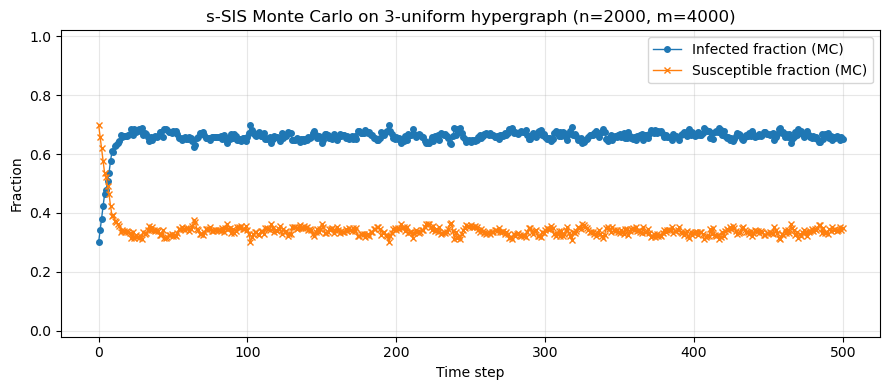

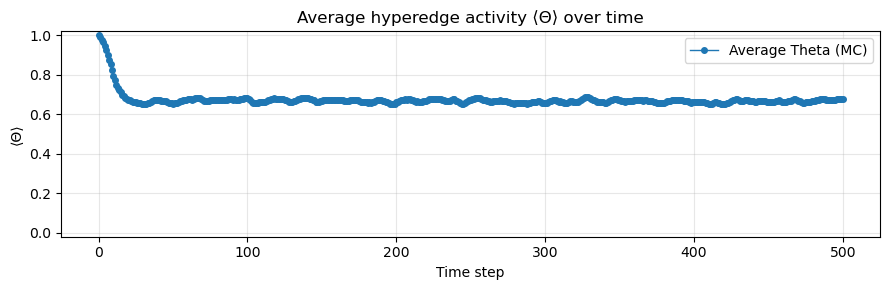

Initial infected fraction (t=0) = 0.3000
Final infected fraction (t=500) = 0.6510
Initial mean Theta = 1.0000
Final mean Theta = 0.6777


In [3]:
# -------------------- main runner for SISHyperMC --------------------
if __name__ == "__main__":
    # --- 仿真参数（可按需修改） ---
    n = 2000
    kappa = 6.0
    beta = 0.3
    mu = 0.2
    T = 500
    init_frac = 0.3
    seed = 12345
    eta = 0.5
    gamma = 0.3
    p_smooth = 0.6   # EMA 平滑参数，参考讨论可改为 0/0.5/0.9 等

    # --- 生成超图 ---
    print("Generating 3-uniform hypergraph H(n,m,3)...")
    hyperedges = generate_hypergraph_H_n_m_3(n=n, kappa=kappa, seed=seed, batch_size=3000)
    m = hyperedges.shape[0]
    print(f"Generated hypergraph: n={n}, m={m}, average_degree(kappa)≈{kappa}")

    # --- 实例化并运行 Monte-Carlo 模型 ---
    print("Initializing SISHyperMC model ...")
    mc_model = SISHyperMC(hyperedges=hyperedges, n=n,
                         beta_d=beta, mu=mu, eta=eta, gamma=gamma,
                         T=T, init_frac=init_frac, seed=seed, p_smooth=p_smooth)
    print("Running Monte-Carlo simulation ... (this may take a few seconds for n=2000, T=100)")
    rho_mc, theta_mc = mc_model.run(verbose=True)

    # --- 绘图：I/S 随时间与 Theta ---
    ts = np.arange(len(rho_mc))

    # 感染/易感随时间
    plt.figure(figsize=(9,4))
    plt.plot(ts, rho_mc, marker='o', linewidth=1, markersize=4, label='Infected fraction (MC)')
    plt.plot(ts, 1.0 - rho_mc, marker='x', linewidth=1, markersize=4, label='Susceptible fraction (MC)')
    plt.xlabel("Time step")
    plt.ylabel("Fraction")
    plt.title(f"s-SIS Monte Carlo on 3-uniform hypergraph (n={n}, m={m})")
    plt.ylim(-0.02, 1.02)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Theta 时间序列
    plt.figure(figsize=(9,3))
    plt.plot(ts, theta_mc, marker='o', linewidth=1, markersize=4, label='Average Theta (MC)')
    plt.xlabel("Time step")
    plt.ylabel("⟨Θ⟩")
    plt.title("Average hyperedge activity ⟨Θ⟩ over time")
    plt.ylim(-0.02, 1.02)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- 输出简单统计信息 ---
    print(f"Initial infected fraction (t=0) = {rho_mc[0]:.4f}")
    print(f"Final infected fraction (t={T}) = {rho_mc[-1]:.4f}")
    print(f"Initial mean Theta = {theta_mc[0]:.4f}")
    print(f"Final mean Theta = {theta_mc[-1]:.4f}")

    # Optional: save arrays to disk (uncomment if needed)
    # np.save("rho_mc.npy", rho_mc)
    # np.save("theta_mc.npy", theta_mc)
    # np.save("hyperedges.npy", hyperedges)
